In [1]:
#Author: Maciej Brzozowski

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from uncertainties import ufloat
from uncertainties.umath import sqrt
from odrpack import odr_fit
%matplotlib inline
plt.ion()

In [3]:
multimetr_error=0.001*60 #cyfry
multimetr_rel_error=0.0006

def error(data):
    return (data*multimetr_rel_error+multimetr_error)/ np.sqrt(3)

def process(data,instrument_error):
    return ufloat(np.mean(data),error(data,instrument_error))

def printer(*args):
    print(*('{:.2u}'.format(x) for x in args))
    print(*('{:.2uL}'.format(x) for x in args))

In [4]:
df = pd.read_csv("data.csv",dtype=float)
df["T_err"] = np.ones_like(df["T"])
df["U_err"] = error(df["U"])
df.tail()

,T,U,T_err,U_err
114,83.0,3.631,1.0,0.035899
115,84.0,3.688,1.0,0.035919
116,85.0,3.739,1.0,0.035936
117,86.0,3.777,1.0,0.035949
118,87.0,3.833,1.0,0.035969


In [5]:
def analise_data(T_pomiary,U_pomiary,T_error,U_error):
    
    def f(x: np.ndarray,beta: np.ndarray) -> np.ndarray:
        a,b= beta
        return a*x+b
    beta0 = [0.06,0]
    sol = odr_fit(f,T_pomiary,U_pomiary,beta0,weight_x=T_error**-2,weight_y=U_error**-2)
    a,b=sol.beta
    a_err,b_err = sol.sd_beta

    return a,b,a_err,b_err

In [6]:
a,b,a_err,b_err=analise_data(df["T"],df["U"],df["T_err"],df["U_err"])

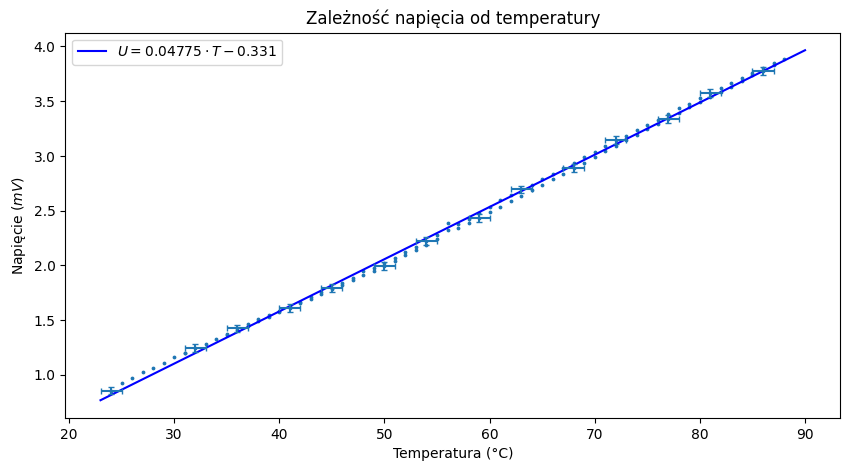

0.04775052701933278 -0.3315717400265692 0.00017823581127356678 0.010786888808674162


In [13]:


fig, ax = plt.subplots(figsize=(10, 5))
x_fit = np.linspace(23, 90, 100)
ax.scatter(df["T"], df["U"],s=3)
ax.plot(x_fit, a * x_fit + b , 'b-',label=r"$U = 0.04775 \cdot T - 0.331$")
ax.errorbar(df["T"][::9],df["U"][::9],xerr=df["T_err"][::9],yerr=df["U_err"][::9],fmt="None",capsize=2)
ax.legend()
ax.set_xlabel("Temperatura (\N{DEGREE SIGN}C)")
ax.set_ylabel("Napięcie ($mV$)")
ax.set_title("Zależność napięcia od temperatury")
plt.show()
print(a,b,a_err,b_err)

In [15]:
a_u = ufloat(a,a_err)
b_u = ufloat(b,b_err)
print(-b_u/a_u)

6.94+/-0.23
